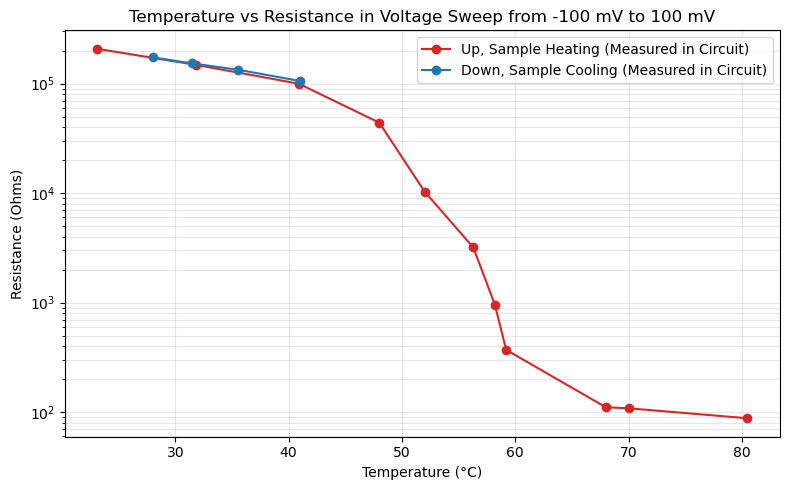

In [5]:
import numpy as np
import matplotlib.pyplot as plt

temperatures = np.array([23.1, 31.8, 40.9, 48, 52, 56.3, 58.2, 59.2, 68, 70, 80.5, 41, 35.5, 31.5, 28])
resistances = np.array([208175, 148692, 99881.5, 44067.9, 10352.5, 3191.96, 960.603, 370.95, 110.956, 108.526, 88.0241, 105858, 134212, 152989, 173959])

# Part 1 = first 11 points, Part 2 = last 4 points (41, 35.5, 31.5, 28)
part1_t, part1_r = temperatures[:11], resistances[:11]
part2_t, part2_r = temperatures[11:], resistances[11:]

plt.figure(figsize=(8, 5))
plt.plot(part1_t, part1_r, 'o-', color='tab:red', label='Up, Sample Heating (Measured in Circuit)')
plt.plot(part2_t, part2_r, 'o-', color='tab:blue', label='Down, Sample Cooling (Measured in Circuit)')

plt.yscale('log')
plt.xlabel('Temperature (°C)')
plt.ylabel('Resistance (Ohms)')
plt.title('Temperature vs Resistance in Voltage Sweep from -100 mV to 100 mV')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


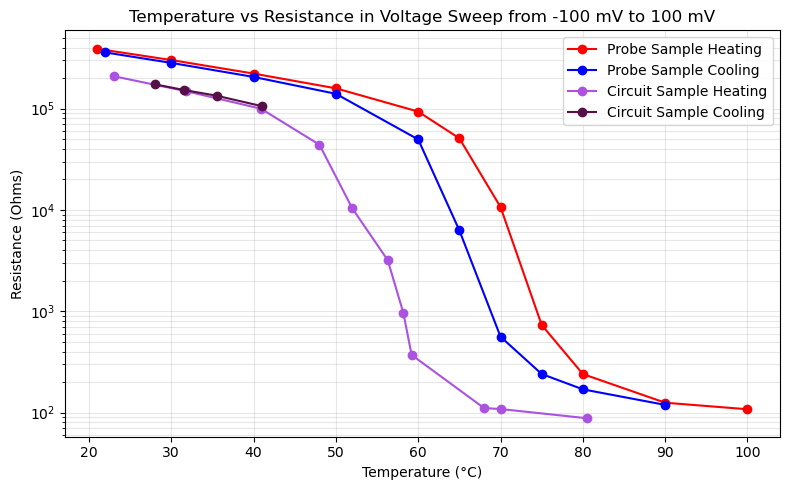

In [4]:
import numpy as np
import matplotlib.pyplot as plt

temperaturesProbe = np.array([21, 30, 40, 50, 60, 65, 70, 75, 80, 90, 100, 
                              90, 80, 75, 70, 65, 60, 50, 40, 30, 22])
resistancesProbe = np.array([389565.08225867274, 301744.21621629596, 221879.97739938478, 
                             158723.28625014226, 93546.95875876902, 50938.88321974158, 
                             10685.901710962731, 733.1249092282038, 240.33401092193776, 
                             125.29427885604268, 108.00012060278029, 
                             119.26113369858736, 169.7989606, 240.5894758598684, #down starts here
                             561.2864448987413, 6287.388628, 49669.11174452618, 
                             140134.252, 205598.75383620014, 282918.10211482685, 358739.1495954983])


temperaturesWire = np.array([23.1, 31.8, 40.9, 48, 52, 56.3, 58.2, 59.2, 68, 70, 80.5, 41, 35.5, 31.5, 28])
resistancesWire = np.array([208175, 148692, 99881.5, 44067.9, 10352.5, 3191.96, 960.603, 370.95, 110.956, 108.526, 88.0241, 105858, 134212, 152989, 173959])

# INITIAL PROBE: Part 1 = first 11 points, Part 2 = last other points
part1_tProbe, part1_rProbe = temperaturesProbe[:11], resistancesProbe[:11]
part2_tProbe, part2_rProbe = temperaturesProbe[11:], resistancesProbe[11:]

# CIRCUIT WIRE: Part 1 = first 11 points, Part 2 = last 4 points (41, 35.5, 31.5, 28)
part1_tWire, part1_rWire = temperaturesWire[:11], resistancesWire[:11]
part2_tWire, part2_rWire = temperaturesWire[11:], resistancesWire[11:]

plt.figure(figsize=(8, 5))

plt.plot(part1_tProbe, part1_rProbe, 'o-', color='red', label='Probe Sample Heating')
plt.plot(part2_tProbe, part2_rProbe, 'o-', color='blue', label='Probe Sample Cooling')

plt.plot(part1_tWire, part1_rWire, 'o-', color='#AB52E0', label='Circuit Sample Heating')
plt.plot(part2_tWire, part2_rWire, 'o-', color='#570F48', label='Circuit Sample Cooling')


plt.yscale('log')
plt.xlabel('Temperature (°C)')
plt.ylabel('Resistance (Ohms)')
plt.title('Temperature vs Resistance in Voltage Sweep from -100 mV to 100 mV')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


PROBE HYSTERESIS MIDPOINT
Left boundary:        53.354 °C
Right boundary:       81.770 °C
Hysteresis width:     28.416 °C

Midpoint temperature: 67.562 °C
Heating resistance:   22881.1 Ω
Cooling resistance:   1822.85 Ω
Midpoint resistance:   6458.24 Ω


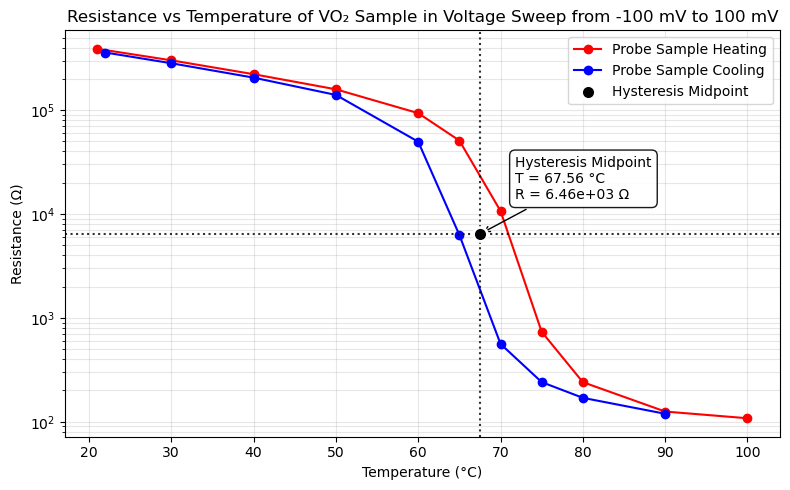

In [1]:
# ============================================================
# PROBE DATA — HEATING/COOLING HYSTERESIS MIDPOINT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Probe data
# ------------------------------------------------------------

temperaturesProbe = np.array([
    21, 30, 40, 50, 60, 65, 70, 75, 80, 90, 100,
    90, 80, 75, 70, 65, 60, 50, 40, 30, 22
])

resistancesProbe = np.array([
    389565.08225867274,
    301744.21621629596,
    221879.97739938478,
    158723.28625014226,
    93546.95875876902,
    50938.88321974158,
    10685.901710962731,
    733.1249092282038,
    240.33401092193776,
    125.29427885604268,
    108.00012060278029,
    119.26113369858736,
    169.7989606,
    240.5894758598684,
    561.2864448987413,
    6287.388628,
    49669.11174452618,
    140134.252,
    205598.75383620014,
    282918.10211482685,
    358739.1495954983
])

# ------------------------------------------------------------
# Separate heating and cooling
# First 11 points = heating
# Last 10 points = cooling
# ------------------------------------------------------------

part1_tProbe = temperaturesProbe[:11]
part1_rProbe = resistancesProbe[:11]

part2_tProbe = temperaturesProbe[11:]
part2_rProbe = resistancesProbe[11:]

# ------------------------------------------------------------
# Sort cooling data by temperature for interpolation
# ------------------------------------------------------------

cool_sort = np.argsort(part2_tProbe)

cool_t = part2_tProbe[cool_sort]
cool_r = part2_rProbe[cool_sort]

# ------------------------------------------------------------
# Common temperature range
# ------------------------------------------------------------

Tmin = max(
    part1_tProbe.min(),
    cool_t.min()
)

Tmax = min(
    part1_tProbe.max(),
    cool_t.max()
)

# High-resolution temperature grid
T = np.linspace(
    Tmin,
    Tmax,
    5000
)

# ------------------------------------------------------------
# Interpolate in log10 resistance space
# ------------------------------------------------------------

logR_heating = np.interp(
    T,
    part1_tProbe,
    np.log10(part1_rProbe)
)

logR_cooling = np.interp(
    T,
    cool_t,
    np.log10(cool_r)
)

# ------------------------------------------------------------
# Calculate hysteresis separation
# ------------------------------------------------------------

separation = np.abs(
    logR_heating - logR_cooling
)

max_separation = separation.max()

# Use 10% of maximum separation
threshold = 0.10 * max_separation

mask = separation >= threshold

T_gap = T[mask]

# ------------------------------------------------------------
# Hysteresis boundaries
# ------------------------------------------------------------

T_left = T_gap.min()
T_right = T_gap.max()

gap_width = T_right - T_left

# ------------------------------------------------------------
# Hysteresis midpoint temperature
# ------------------------------------------------------------

T_mid = (
    T_left + T_right
) / 2

# ------------------------------------------------------------
# Heating and cooling resistance at midpoint temperature
# ------------------------------------------------------------

logR_heating_mid = np.interp(
    T_mid,
    T,
    logR_heating
)

logR_cooling_mid = np.interp(
    T_mid,
    T,
    logR_cooling
)

R_heating_mid = 10 ** logR_heating_mid
R_cooling_mid = 10 ** logR_cooling_mid

# ------------------------------------------------------------
# Geometric midpoint resistance
#
# Because resistance is plotted on a logarithmic scale:
#
# R_mid = sqrt(R_heating * R_cooling)
# ------------------------------------------------------------

R_mid = np.sqrt(
    R_heating_mid * R_cooling_mid
)

# ------------------------------------------------------------
# Print midpoint results
# ------------------------------------------------------------

print("=" * 65)
print("PROBE HYSTERESIS MIDPOINT")
print("=" * 65)

print(f"Left boundary:        {T_left:.3f} °C")
print(f"Right boundary:       {T_right:.3f} °C")
print(f"Hysteresis width:     {gap_width:.3f} °C")

print()
print(f"Midpoint temperature: {T_mid:.3f} °C")
print(f"Heating resistance:   {R_heating_mid:.6g} Ω")
print(f"Cooling resistance:   {R_cooling_mid:.6g} Ω")
print(f"Midpoint resistance:   {R_mid:.6g} Ω")

print("=" * 65)

# ------------------------------------------------------------
# Plot probe heating/cooling curves
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    part1_tProbe,
    part1_rProbe,
    'o-',
    color='red',
    label='Probe Sample Heating',
)

plt.plot(
    part2_tProbe,
    part2_rProbe,
    'o-',
    color='blue',
    label='Probe Sample Cooling',
)

# ------------------------------------------------------------
# Plot hysteresis midpoint
# ------------------------------------------------------------

plt.scatter(
    T_mid,
    R_mid,
    color='black',
    s=100,
    marker='o',
    edgecolor='white',
    linewidth=2,
    zorder=20,
    label='Hysteresis Midpoint'
)

# Midpoint temperature line
plt.axvline(
    T_mid,
    color='black',
    linestyle=':',
    linewidth=1.5,
    alpha=0.8
)

# Midpoint resistance line
plt.axhline(
    R_mid,
    color='black',
    linestyle=':',
    linewidth=1.5,
    alpha=0.8
)

# ------------------------------------------------------------
# Midpoint annotation
# ------------------------------------------------------------

plt.annotate(
    f"Hysteresis Midpoint\n"
    f"T = {T_mid:.2f} °C\n"
    f"R = {R_mid:.3g} Ω",
    xy=(T_mid, R_mid),
    xytext=(25, 25),
    textcoords='offset points',
    fontsize=10,
    bbox=dict(
        boxstyle='round,pad=0.4',
        fc='white',
        ec='black',
        alpha=0.9
    ),
    arrowprops=dict(
        arrowstyle='->',
        color='black'
    )
)

temperaturesWire = np.array([23.1, 31.8, 40.9, 48, 52, 56.3, 58.2, 59.2, 68, 70, 80.5, 41, 35.5, 31.5, 28])
resistancesWire = np.array([208175, 148692, 99881.5, 44067.9, 10352.5, 3191.96, 960.603, 370.95, 110.956, 108.526, 88.0241, 105858, 134212, 152989, 173959])

# # CIRCUIT WIRE: Part 1 = first 11 points, Part 2 = last 4 points (41, 35.5, 31.5, 28)
# part1_tWire, part1_rWire = temperaturesWire[:11], resistancesWire[:11]
# part2_tWire, part2_rWire = temperaturesWire[11:], resistancesWire[11:]

# plt.plot(part1_tWire, part1_rWire, 'o-', color='#AB52E0', label='Circuit Sample Heating')
# plt.plot(part2_tWire, part2_rWire, 'o-', color='#570F48', label='Circuit Sample Cooling')


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.yscale('log')
plt.xlabel('Temperature (°C)')
plt.ylabel('Resistance (Ω)')
plt.title('Resistance vs Temperature of VO₂ Sample in Voltage Sweep from -100 mV to 100 mV')
plt.grid(
    True,
    which='both',
    alpha=0.3
)
plt.legend()
plt.tight_layout()
plt.show()

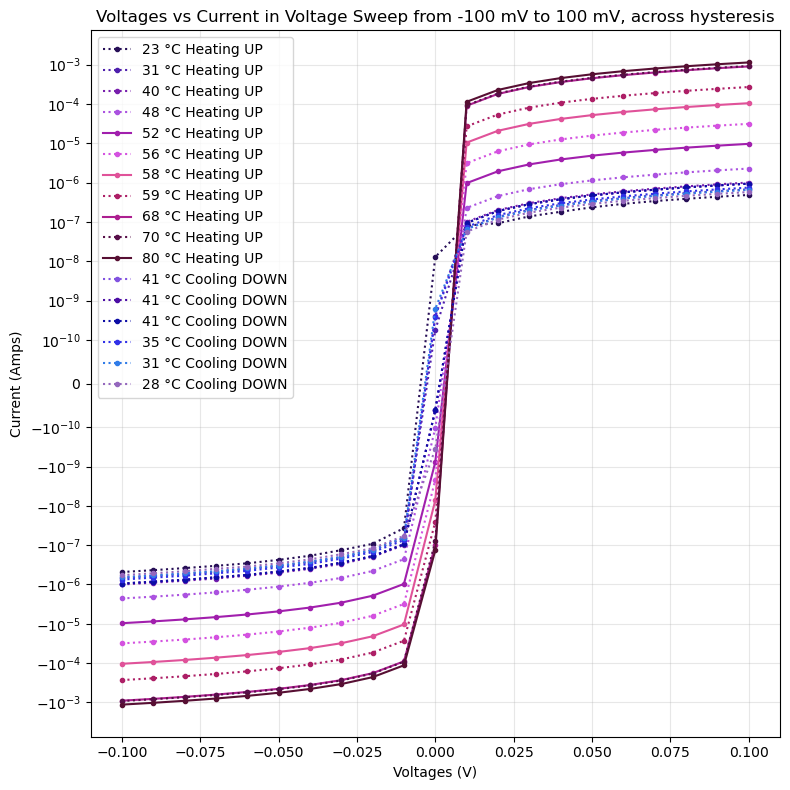

In [17]:
import numpy as np
import matplotlib.pyplot as plt

voltages = np.array([-0.100008257, -0.090007037, -0.080008298, -0.070006579, -0.060007542, -0.050005935, -0.040006898,
                     -0.030004891, -0.020004777, -0.010002901, -2.24596E-06, 0.009995064, 0.019994695, 0.029994603,
                     0.039994095, 0.049995787, 0.059994295, 0.069996372, 0.079993278, 0.089994542, 0.09999238])

current_23up = np.array([-4.8224E-07, -4.33003E-07, -3.82728E-07, -3.35694E-07, -2.89485E-07, -2.36703E-07, -1.85677E-07,
                         -1.33978E-07, -9.2499E-08, -3.69029E-08, 1.28689E-08, 8.07353E-08, 9.26306E-08, 1.38014E-07,
                         1.8079E-07, 2.3479E-07, 2.8809E-07, 3.3833E-07, 3.8708E-07, 4.35669E-07, 4.84563E-07])

current_31up = np.array([-6.72945E-07, -6.0551E-07, -5.38207E-07, -4.70923E-07, -4.03875E-07, -3.36492E-07, -2.689E-07,
                         -2.01426E-07, -1.34765E-07, -6.7287E-08, 1.77769E-10, 6.75322E-08, 1.34562E-07, 2.01705E-07,
                         2.69089E-07, 3.36584E-07, 4.03461E-07, 4.70571E-07, 5.37769E-07, 6.04652E-07, 6.72182E-07])

current_40up = np.array([-1.00038E-06, -9.00948E-07, -8.01849E-07, -7.05159E-07, -5.98806E-07, -5.00809E-07, -4.00929E-07,
                         -2.98936E-07, -1.979E-07, -9.90905E-08, 3.9946E-10, 1.00138E-07, 1.99961E-07, 3.00361E-07,
                         4.0036E-07, 5.00308E-07, 6.00627E-07, 7.00456E-07, 8.00602E-07, 9.00928E-07, 1.00106E-06])

current_48up = np.array([-2.2678E-06, -2.04141E-06, -1.8148E-06, -1.58792E-06, -1.36106E-06, -1.13397E-06, -9.07173E-07,
                         -6.80606E-07, -4.5389E-07, -2.27157E-07, -1.04818E-10, 2.26664E-07, 4.53777E-07, 6.80928E-07,
                         9.07956E-07, 1.13495E-06, 1.36184E-06, 1.58904E-06, 1.81637E-06, 2.04323E-06, 2.26986E-06])

current_52up = np.array([-9.65746E-06, -8.69882E-06, -7.73177E-06, -6.76173E-06, -5.7953E-06, -4.83069E-06, -3.86593E-06,
                         -2.90034E-06, -1.93431E-06, -9.67855E-07, -7.67153E-10, 9.68045E-07, 1.93489E-06, 2.90149E-06,
                         3.86689E-06, 4.83126E-06, 5.7945E-06, 6.75747E-06, 7.72062E-06, 8.68459E-06, 9.64932E-06])

current_56up = np.array([-3.14771E-05, -2.83264E-05, -2.51752E-05, -2.20113E-05, -1.88604E-05, -1.57133E-05, -1.2565E-05,
                         -9.41785E-06, -6.253E-06, -3.12651E-06, -2.18146E-09, 3.121E-06, 6.25202E-06, 9.37176E-06,
                         1.25053E-05, 1.56302E-05, 1.87532E-05, 2.18725E-05, 2.49734E-05, 2.80572E-05, 3.11254E-05])

current_58up = np.array([-0.000104014, -9.35728E-05, -8.31692E-05, -7.2782E-05, -6.23717E-05, -5.19736E-05, -4.15793E-05,
                         -3.11872E-05, -2.07952E-05, -1.03978E-05, -7.22559E-09, 1.03903E-05, 2.07765E-05, 3.11593E-05,
                         4.15526E-05, 5.19565E-05, 6.23796E-05, 7.28437E-05, 8.33584E-05, 9.39205E-05, 0.000104418])

current_59up = np.array([-0.000270143, -0.000242934, -0.000215825, -0.000188789, -0.000161847, -0.000134968, -0.000108016,
                         -8.09555E-05, -5.38697E-05, -2.69502E-05, -2.54788E-08, 2.69006E-05, 5.38299E-05, 8.07538E-05,
                         0.000107737, 0.000134756, 0.000161645, 0.000188471, 0.000215369, 0.000242223, 0.000269107])

current_68up = np.array([-0.000902517, -0.000812125, -0.000721792, -0.000631627, -0.000541336, -0.000451011, -0.000360797,
                         -0.000270627, -0.000180476, -9.02677E-05, -9.88226E-08, 8.99144E-05, 0.000179925, 0.000269913,
                         0.000359919, 0.00044996, 0.000539959, 0.000629959, 0.00071999, 0.000810022, 0.000900054])

current_70up = np.array([-0.000921111, -0.00082908, -0.00073711, -0.000644871, -0.000552675, -0.000460534, -0.000368479,
                         -0.000276404, -0.00018431, -9.2195E-05, -7.92502E-08, 9.20626E-05, 0.000184214, 0.000276345,
                         0.000368496, 0.000460683, 0.000552941, 0.000645187, 0.000737201, 0.00082911, 0.000921548])

current_80up = np.array([-0.001136491, -0.001022635, -0.000908724, -0.000795045, -0.000681379, -0.000568119, -0.000454743,
                         -0.000341137, -0.00022747, -0.000113777, -1.3526E-07, 0.000113419, 0.00022698, 0.000340537,
                         0.000454109, 0.000567854, 0.000681504, 0.000795005, 0.000908489, 0.001022111, 0.001136028])

current_41down = np.array([-0.00000095, -0.00000085, -0.00000076, -0.00000066, -0.00000057, -0.00000047, -0.00000038,
                           -0.00000028, -0.00000019, -0.000000095, -6.1E-11, 9.42E-08, 0.000000189, 0.000000283,
                           0.000000377, 0.000000471, 0.000000565, 0.000000659, 0.000000753, 0.000000847, 0.000000939])

current_35down = np.array([-0.00000075, -0.00000067, -0.0000006, -0.00000052, -0.00000045, -0.00000037, -0.0000003,
                           -0.00000022, -0.00000015, -0.000000075, 3.91E-10, 7.45E-08, 0.000000149, 0.000000223,
                           0.000000298, 0.000000372, 0.000000446, 0.000000521, 0.000000596, 0.00000067, 0.000000744])

current_31down = np.array([-0.00000065, -0.00000059, -0.00000052, -0.00000046, -0.00000039, -0.00000033, -0.00000026,
                           -0.0000002, -0.00000013, -0.000000064, 6.15E-10, 6.53E-08, 0.00000013, 0.000000195,
                           0.000000261, 0.000000326, 0.000000392, 0.000000458, 0.000000522, 0.000000588, 0.000000653])

current_28down = np.array([-0.00000058, -0.00000052, -0.00000046, -0.0000004, -0.00000035, -0.00000029, -0.00000023,
                           -0.00000017, -0.00000012, -0.000000058, -3.6E-10, 5.63E-08, 0.000000114, 0.000000172,
                           0.00000023, 0.000000287, 0.000000344, 0.000000402, 0.00000046, 0.000000517, 0.000000574])


plt.figure(figsize=(8, 8))

plt.plot(voltages, current_23up, '.:', color='#270F57', label='23 °C Heating UP')
plt.plot(voltages, current_31up, '.:', color='#4E1FAD', label='31 °C Heating UP')
plt.plot(voltages, current_40up, '.:', color='#781FAD', label='40 °C Heating UP')
plt.plot(voltages, current_48up, '.:', color='#AB52E0', label='48 °C Heating UP')

plt.plot(voltages, current_52up, '.-', color='#A11FAD', label='52 °C Heating UP')
plt.plot(voltages, current_56up, '.:', color='#D452E0', label='56 °C Heating UP')
plt.plot(voltages, current_58up, '.-', color='#E05299', label='58 °C Heating UP')
plt.plot(voltages, current_59up, '.:', color='#AD1F66', label='59 °C Heating UP')
plt.plot(voltages, current_68up, '.-', color='#AD1F90', label='68 °C Heating UP')
plt.plot(voltages, current_70up, '.:', color='#570F48', label='70 °C Heating UP')
plt.plot(voltages, current_80up, '.-', color='#570F33', label='80 °C Heating UP')

plt.plot(voltages, current_41down, '.:', color='#8152E0', label='41 °C Cooling DOWN')
plt.plot(voltages, current_41down, '.:', color='#4c0da5', label='41 °C Cooling DOWN')
plt.plot(voltages, current_41down, '.:', color='#0d0da5', label='41 °C Cooling DOWN')
plt.plot(voltages, current_35down, '.:', color='#3030e8', label='35 °C Cooling DOWN')
plt.plot(voltages, current_31down, '.:', color='#307ce8', label='31 °C Cooling DOWN')
plt.plot(voltages, current_28down, '.:', color='tab:purple', label='28 °C Cooling DOWN')

cool_light_purples = [
    "#e5e0ff", "#d4d0fa", "#c3bef7", "#b2adf4", "#a5a1f2",
    "#eae3ff", "#ddd2ff", "#cebfff", "#bfadff", "#b09cff",
    '#F0A8CC', '#E052C3', '#F0A8E1', '#EAA8F0', '#D452E0',
    '#D5A8F0', '#AB52E0', '#C0A8F0', '#8152E0'
]

blue_shades = [
    "#200546", "#4c0da5", "#7c30e8", "#b792eb", "#e2d6f4",
    "#050546", "#0d0da5", "#3030e8", "#9292eb", "#d6d6f4",
    "#052046", "#0d4ca5", "#307ce8", "#92b7eb", "#d6e2f4"
]


plt.yscale('symlog', linthresh=1e-10)
plt.xlabel('Voltages (V)')
plt.ylabel('Current (Amps)')
plt.title('Voltages vs Current in Voltage Sweep from -100 mV to 100 mV, across hysteresis')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
